In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

import logging

# Configure logging to show INFO level messages
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s -| %(levelname)s - %(message)s'
)

# Optional: Set specific logger level for pyedm4hep
logger = logging.getLogger('pyedm4hep.event_batch')
logger.setLevel(logging.INFO)


## Loading

In [128]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

calo_digi_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep_digitized.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 1), full_load=False, detector_params=detector_params, condense_calo=True)

In [129]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
print(f"""
Unique events IDs in particles: {calo_particles.event_id.unique()}
Length of particles: {len(calo_particles)}
Length of calo_tracker_hits: {len(calo_tracker_hits)}
Length of calo_truth_hits: {len(calo_truth_hits)}
Length of calo_digi_contributions: {len(calo_digi_contributions)}
Length of calo_digi_hits: {len(calo_digi_hits)}
Events with non-empty calo_digi_hits: {calo_digi_hits.event_id.unique()}
""")

pyedm4hep.event_batch -| INFO -   ↳ PixelBarrelReadout: 0.1242s (43967 rows)
pyedm4hep.event_batch -| INFO -       • read: 0.0575s, to_df: 0.0254s, links: 0.0241s, derived: 0.0101s
pyedm4hep.event_batch -| INFO -   ↳ PixelEndcapReadout: 0.0697s (40995 rows)
pyedm4hep.event_batch -| INFO -       • read: 0.0230s, to_df: 0.0153s, links: 0.0166s, derived: 0.0082s
pyedm4hep.event_batch -| INFO -   ↳ ShortStripBarrelReadout: 0.0688s (45304 rows)
pyedm4hep.event_batch -| INFO -       • read: 0.0203s, to_df: 0.0153s, links: 0.0168s, derived: 0.0093s
pyedm4hep.event_batch -| INFO -   ↳ ShortStripEndcapReadout: 0.0781s (40931 rows)
pyedm4hep.event_batch -| INFO -       • read: 0.0213s, to_df: 0.0158s, links: 0.0267s, derived: 0.0093s
pyedm4hep.event_batch -| INFO -   ↳ LongStripBarrelReadout: 0.1205s (19707 rows)
pyedm4hep.event_batch -| INFO -       • read: 0.0721s, to_df: 0.0103s, links: 0.0278s, derived: 0.0058s
pyedm4hep.event_batch -| INFO -   ↳ LongStripEndcapReadout: 0.0666s (24004 rows)


Any NAN values:  event_id       False
subentry       False
energy         False
time           False
particle_id    False
detector       False
hit_index      False
cellID         False
dtype: bool


pyedm4hep.utils -| INFO -       ✓ condensation complete: 4.5819s (1504440 condensed rows)
pyedm4hep.event_batch -| INFO -   ↳ condensation: 4.7271s (1504440 condensed rows)
pyedm4hep.event_batch -| INFO - ⏱️  _load_calo_contributions: 10.0536s (1504440 contributions)
pyedm4hep.event_batch -| INFO -   ↳ condensation: 4.7271s (1504440 condensed rows)
pyedm4hep.event_batch -| INFO - ⏱️  _load_calo_contributions: 10.0536s (1504440 contributions)
pyedm4hep.event_batch -| INFO -   ↳ particles loaded: 0.2650s (184995 rows)
pyedm4hep.event_batch -| INFO -   ↳ particles loaded: 0.2650s (184995 rows)
pyedm4hep.event_batch -| INFO -   ↳ links loaded: 0.0673s (parents=325032, daughters=0)
pyedm4hep.event_batch -| INFO - ⏱️  _load_particles_and_links: 1.9253s total
pyedm4hep.event_batch -| INFO -   ↳ links loaded: 0.0673s (parents=325032, daughters=0)
pyedm4hep.event_batch -| INFO - ⏱️  _load_particles_and_links: 1.9253s total
pyedm4hep.utils -| INFO -   ⏱️  groupby tracker_hits (214908 rows)...
py


Unique events IDs in particles: [0]
Length of particles: 184995
Length of calo_tracker_hits: 214908
Length of calo_truth_hits: 1073103
Length of calo_digi_contributions: 1504440
Length of calo_digi_hits: 390400
Events with non-empty calo_digi_hits: [0]



In [130]:
calo_digi_contributions

,energy,time,particle_id,cellID,detector,hit_index,event_id
0,2.560871e-05,257.313354,75387,18347664899104835600,ECalBarrelCollection,0,0
1,3.151182e-04,261.257935,75387,18345131624315160592,ECalBarrelCollection,1,0
2,2.697902e-05,5718.284180,75387,18389041540292096016,ECalBarrelCollection,2,0
3,9.121775e-05,5718.079102,75387,18390730433102032912,ECalBarrelCollection,3,0
4,2.949213e-07,5713.619141,75387,18367368151768975376,ECalBarrelCollection,4,0
...,...,...,...,...,...,...,...
1504435,6.664368e-07,107.149147,184887,18439707212189473044,HCalEndcapCollection,1073098,0
1504436,1.103416e-07,410.390442,184886,18438299824421015828,HCalEndcapCollection,1073099,0
1504437,1.593765e-07,1076.835327,184886,18438581307987659028,HCalEndcapCollection,1073100,0
1504438,2.099848e-05,117.318466,184886,18438862778669732116,HCalEndcapCollection,1073101,0


In [131]:
calo_truth_hits

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,0,0,18347664899104835600,2.560871e-05,5.193779e+02,-1200.581543,-1795.199951,0,1,ECalBarrelCollection,1308.109131,2221.236572,-1.162502,2.511883,-1.121812
1,0,1,18345131624315160592,3.151182e-04,5.406360e+02,-1251.902954,-1841.099976,1,12,ECalBarrelCollection,1363.652588,2291.112549,-1.163137,2.504088,-1.108646
2,0,2,18389041540292096016,2.697902e-05,-1.262500e+03,193.800003,-1050.599976,12,13,ECalBarrelCollection,1277.288086,1653.851562,2.989277,2.259121,-0.750160
3,0,3,18390730433102032912,9.121775e-05,-1.262500e+03,142.800003,-1020.000000,13,14,ECalBarrelCollection,1270.550293,1629.324341,3.028962,2.247243,-0.734855
4,0,4,18367368151768975376,2.949213e-07,-5.066967e+02,1156.639526,-1438.199951,14,15,ECalBarrelCollection,1262.757568,1913.890259,1.983691,2.421059,-0.976286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073098,0,205668,18439707212189473044,6.664368e-07,-3.425820e+02,-1062.247437,3749.500000,4986008,4986009,HCalEndcapCollection,1116.123657,3912.094238,-1.882771,0.289320,1.926358
1073099,0,205669,18438299824421015828,1.103416e-07,9.180376e-15,-962.489136,3749.500000,4986009,4986012,HCalEndcapCollection,962.489136,3871.063721,-1.570796,0.251273,2.069083
1073100,0,205670,18438581307987659028,1.593765e-07,4.352419e+02,-893.979370,3749.500000,4986012,4986020,HCalEndcapCollection,994.301086,3879.095947,-1.117717,0.259216,2.037619
1073101,0,205671,18438862778669732116,2.099848e-05,3.000000e+01,-1022.489136,4004.500000,4986020,4986022,HCalEndcapCollection,1022.929138,4133.086426,-1.541465,0.250097,2.073823


In [134]:
calo_digi_contributions.iloc[4986020:4986022]

,energy,time,particle_id,cellID,detector,hit_index,event_id


In [97]:
calo_digi_contributions[calo_digi_contributions.event_id==1].iloc[4880531:4880533].energy.sum()

np.float32(5.0071282e-08)

In [137]:
calo_digi_contributions[(calo_digi_contributions.event_id==0) & (calo_digi_contributions.cellID==18438299824421015828)].energy.sum()

np.float32(1.1034163e-07)

## Roadmap

1. How many tracker hits vs sim calo hits?
2. How many sim calo hits vs digi calo hits?
3. What is the maximum energy I can cut that retains the resolution of electrons and pions? Use single particles
    1. Apply cut E_cut at sim level
    2. Calculate sum and merge
    3. Calculate mean resolution and variance
    4. Don't want to drop more than ~10% relative to pre-cut
4. Given max energy cut...
5. How many contributions per cell?
6. What is the energy of the first, second, third, fourth contribution to each cell (assuming contributions are condensed)? Absolute and relative to cell energy
7. For "important particles" (>1GeV), how much of their energy is left as >= second, third, fourth contribution to a cell

In [103]:
ecal_threshold = 5e-5
hcal_threshold = 0.00025

ecal_mask_sim = calo_truth_hits['detector'].str.contains('ECal')
hcal_mask_sim = calo_truth_hits['detector'].str.contains('HCal')

print("Before thresholding:", len(calo_truth_hits))

# Apply energy thresholds to sim hits
thresholded_sim = calo_truth_hits[
    ((ecal_mask_sim) & (calo_truth_hits['energy'] >= ecal_threshold)) |
    ((hcal_mask_sim) & (calo_truth_hits['energy'] >= hcal_threshold))
].copy()

print("After thresholding:", len(thresholded_sim))

thresholded_sim = thresholded_sim.merge(calo_digi_hits[['event_id', 'cellID']], on=['event_id', 'cellID'], how='inner')

print("After matching to digi hits:", len(thresholded_sim))

Before thresholding: 2100215
After thresholding: 1467877
After matching to digi hits: 777421
After matching to digi hits: 777421


In [105]:
num_tracker_hits = calo_tracker_hits.groupby("event_id").count()["subentry"].values
num_sim_calo_hits = calo_truth_hits.groupby("event_id").count()["subentry"].values
num_digi_calo_hits = calo_digi_hits.groupby("event_id").count()["subentry"].values
num_thresholded_sim_calo_hits = thresholded_sim.groupby("event_id").count()["subentry"].values

In [106]:
print(f"""
Number of tracker hits per event: {num_tracker_hits}
Number of sim calo hits per event: {num_sim_calo_hits}
Number of digi calo hits per event: {num_digi_calo_hits}
Number of thresholded sim calo hits per event: {num_thresholded_sim_calo_hits}
""")


Number of tracker hits per event: [214908 194562]
Number of sim calo hits per event: [1073103 1027112]
Number of digi calo hits per event: [390400 387021]
Number of thresholded sim calo hits per event: [390400 387021]



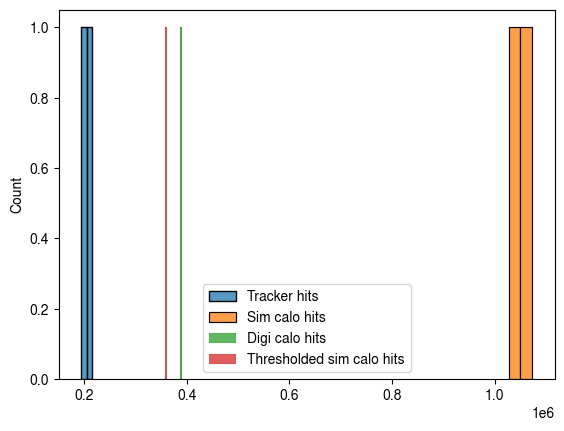

In [83]:
sns.histplot(num_tracker_hits, label="Tracker hits")
sns.histplot(num_sim_calo_hits, label="Sim calo hits")
sns.histplot(num_digi_calo_hits, label="Digi calo hits")
sns.histplot(num_thresholded_sim_calo_hits, label="Thresholded sim calo hits")
plt.legend()

## Exact k4ODD Digitization Cuts

Apply the exact same cuts as k4ODD to see if we can recover `calo_digi_hits` from `calo_truth_hits`:

**Energy Thresholds:**
- ECAL: 5.0e-5 GeV (0.00005 GeV)
- HCAL: 0.00025 GeV

**Timing Windows:**
- ECAL: -1.0 ns to 10.0 ns
- HCAL: -1.0 ns to 10.0 ns
- UseEcalTiming = 1, UseHcalTiming = 1
- ECALSimpleTimingCut = True, HCALSimpleTimingCut = True

In [14]:
# Check what timing information is available in contributions
print("Columns in calo_digi_contributions:")
print(calo_digi_contributions.columns.tolist())
print("\nSample of time values:")
if 'time' in calo_digi_contributions.columns:
    print(calo_digi_contributions['time'].describe())
    print(f"Time range: [{calo_digi_contributions['time'].min():.3f}, {calo_digi_contributions['time'].max():.3f}] ns")
    print(f"\nSample contributions:")
    print(calo_digi_contributions[['event_id', 'cellID', 'energy', 'time', 'detector']].head(20))
else:
    print("No 'time' column in contributions!")

Columns in calo_digi_contributions:
['energy', 'time', 'particle_id', 'cellID', 'detector', 'hit_index', 'event_id']

Sample of time values:
count    1.891067e+07
mean     4.305133e+02
std      1.347529e+03
min     -1.024935e+01
25%      1.031988e+01
50%      1.718204e+01
75%      1.280709e+02
max      5.261748e+05
Name: time, dtype: float64
Time range: [-10.249, 526174.750] ns

Sample contributions:
count    1.891067e+07
mean     4.305133e+02
std      1.347529e+03
min     -1.024935e+01
25%      1.031988e+01
50%      1.718204e+01
75%      1.280709e+02
max      5.261748e+05
Name: time, dtype: float64
Time range: [-10.249, 526174.750] ns

Sample contributions:
    event_id                cellID        energy         time  \
0          0  18347664899104835600  2.560871e-05   257.313354   
1          0  18345131624315160592  3.151182e-04   261.257935   
2          0  18389041540292096016  2.697902e-05  5718.284180   
3          0  18390730433102032912  9.121775e-05  5718.079102   
4       

## Test: Energy threshold applied AFTER merging (at cell level)

What if k4ODD:
1. Merges ALL contributions by cell (no energy cut)
2. Applies timing cuts to individual contributions, but still merges them
3. Then applies energy threshold to the final cell total

Let's test this hypothesis:

In [102]:
# Test: Apply timing window to contributions, merge ALL, then threshold at cell level
print("=== Test: Threshold AFTER merging (cell level) ===\n")

ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
ecal_time_min = -1.0  # ns
ecal_time_max = 10.0  # ns
hcal_time_min = -1.0  # ns
hcal_time_max = 10.0  # ns

ecal_mask = calo_digi_contributions['detector'].str.contains('ECal')
hcal_mask = calo_digi_contributions['detector'].str.contains('HCal')

print(f"Contributions before any filtering: {len(calo_digi_contributions)}")

# Step 1: Apply timing cuts to contributions only (NOT energy)
if 'time' in calo_digi_contributions.columns:
    contributions_timing_filtered = calo_digi_contributions[
        ((ecal_mask) & 
         (calo_digi_contributions['time'] >= ecal_time_min) &
         (calo_digi_contributions['time'] <= ecal_time_max)) |
        ((hcal_mask) & 
         (calo_digi_contributions['time'] >= hcal_time_min) &
         (calo_digi_contributions['time'] <= hcal_time_max))
    ].copy()
    print(f"Contributions after TIMING filter only: {len(contributions_timing_filtered)}")
else:
    contributions_timing_filtered = calo_digi_contributions.copy()
    print("No timing filter (no time column)")

# Step 2: Merge ALL remaining contributions by cell
merged_before_threshold = contributions_timing_filtered.groupby(['event_id', 'detector', 'cellID']).agg({
    'energy': 'sum'
}).reset_index()
print(f"Cells after merging (before energy threshold): {len(merged_before_threshold)}")

# Step 3: Apply energy threshold at the cell level
merged_after_threshold = merged_before_threshold[
    ((merged_before_threshold['detector'].str.contains('ECal')) & (merged_before_threshold['energy'] >= ecal_threshold_k4odd)) |
    ((merged_before_threshold['detector'].str.contains('HCal')) & (merged_before_threshold['energy'] >= hcal_threshold_k4odd))
].copy()
print(f"Cells after CELL-LEVEL energy threshold: {len(merged_after_threshold)}")
print(f"Actual digi hits: {len(calo_digi_hits)}")
print(f"Difference: {len(merged_after_threshold) - len(calo_digi_hits)} cells")

=== Test: Threshold AFTER merging (cell level) ===

Contributions before any filtering: 9866558
Contributions before any filtering: 9866558
Contributions after TIMING filter only: 2655826
Contributions after TIMING filter only: 2655826
Cells after merging (before energy threshold): 533387
Cells after merging (before energy threshold): 533387
Cells after CELL-LEVEL energy threshold: 499366
Actual digi hits: 777421
Difference: -278055 cells
Cells after CELL-LEVEL energy threshold: 499366
Actual digi hits: 777421
Difference: -278055 cells


In [101]:
# Compare the cell-level threshold result with digi hits
print("=== Comparing cell-level thresholded cells vs digi hits ===\n")

merged_cells_set = set(zip(merged_after_threshold['event_id'],  merged_after_threshold['cellID']))
digi_cells_set = set(zip(calo_digi_hits['event_id'], calo_digi_hits['cellID']))

cells_only_in_merged = merged_cells_set - digi_cells_set
cells_only_in_digi = digi_cells_set - merged_cells_set
cells_in_both = merged_cells_set & digi_cells_set

print(f"Cells only in merged (threshold at cell level): {len(cells_only_in_merged)}")
print(f"Cells only in digi: {len(cells_only_in_digi)}")
print(f"Cells in both: {len(cells_in_both)}")

# For matched cells, compare energies
if len(cells_in_both) > 0:
    merged_comparison_v2 = merged_after_threshold.merge(
        calo_digi_hits[['event_id', 'cellID', 'energy']], 
        on=['event_id', 'cellID'], 
        suffixes=('_merged', '_digi'),
        how='inner'
    )
    
    merged_comparison_v2['energy_diff'] = merged_comparison_v2['energy_digi'] - merged_comparison_v2['energy_merged']
    merged_comparison_v2['energy_ratio'] = merged_comparison_v2['energy_digi'] / merged_comparison_v2['energy_merged']
    
    print(f"\n=== Energy comparison (merged cell-level threshold vs digi) ===")
    print(f"Mean energy ratio (digi/merged): {merged_comparison_v2['energy_ratio'].mean():.6f}")
    print(f"Energy diff statistics:")
    print(merged_comparison_v2['energy_diff'].describe())
    print(f"\nSample comparisons:")
    print(merged_comparison_v2[['event_id', 'detector', 'cellID', 'energy_merged', 'energy_digi', 'energy_ratio']].head(20))

=== Comparing cell-level thresholded cells vs digi hits ===

Cells only in merged (threshold at cell level): 395907
Cells only in digi: 673962
Cells in both: 103459
Cells only in merged (threshold at cell level): 395907
Cells only in digi: 673962
Cells in both: 103459

=== Energy comparison (merged cell-level threshold vs digi) ===
Mean energy ratio (digi/merged): 48.697781
Energy diff statistics:
count    103459.000000
mean          0.026193
std           0.066346
min          -0.040797
25%           0.007057
50%           0.011940
75%           0.023762
max           3.245545
Name: energy_diff, dtype: float64

Sample comparisons:
    event_id              detector        cellID  energy_merged  energy_digi  \
0          0  ECalBarrelCollection   30082492432       0.000620     0.023266   
1          0  ECalBarrelCollection   38674309136       0.000205     0.007680   
2          0  ECalBarrelCollection   42966937616       0.000073     0.002740   
3          0  ECalBarrelCollection   429

## Systematic Debugging: Step-by-step comparison

Let's trace through exactly what DDCaloDigi does and compare at each step:

In [86]:
# Step 1: Check what we're starting with
print("=== Input Data ===")
print(f"calo_truth_hits (cell-level sim): {len(calo_truth_hits)}")
print(f"calo_digi_contributions (truth contributions): {len(calo_digi_contributions)}")
print(f"calo_digi_hits (output): {len(calo_digi_hits)}")

# Step 2: Check if contributions match truth_hits
print("\n=== Checking relationship between truth_hits and contributions ===")
truth_cells = calo_truth_hits.groupby(['event_id', 'cellID']).size()
contrib_cells = calo_digi_contributions.groupby(['event_id', 'cellID']).size()
print(f"Unique cells in truth_hits: {len(truth_cells)}")
print(f"Unique cells in contributions: {len(contrib_cells)}")

# Are they the same cells?
truth_cell_set = set(truth_cells.index)
contrib_cell_set = set(contrib_cells.index)
print(f"Cells only in truth_hits: {len(truth_cell_set - contrib_cell_set)}")
print(f"Cells only in contributions: {len(contrib_cell_set - truth_cell_set)}")

# Step 3: Check energy correspondence
print("\n=== Energy comparison ===")
truth_energy_by_cell = calo_truth_hits.groupby(['event_id', 'cellID'])['energy'].sum()
contrib_energy_by_cell = calo_digi_contributions.groupby(['event_id', 'cellID'])['energy'].sum()

# For cells in both, compare energies
common_cells = truth_cell_set & contrib_cell_set
if len(common_cells) > 0:
    sample_cells = list(common_cells)[-10:]
    print("Sample energy comparisons (truth_hit vs sum of contributions):")
    for cell in sample_cells:
        truth_e = truth_energy_by_cell[cell]
        contrib_e = contrib_energy_by_cell[cell]
        print(f"  Cell {cell}: truth={truth_e:.6f}, contributions_sum={contrib_e:.6f}, ratio={contrib_e/truth_e:.4f}")

=== Input Data ===
calo_truth_hits (cell-level sim): 2100215
calo_digi_contributions (truth contributions): 9866558
calo_digi_hits (output): 777421

=== Checking relationship between truth_hits and contributions ===


KeyError: 'cellID'

In [ ]:
# Step 4: Apply first threshold (to truth_hits total energy)
print("=== Step 1: First threshold on truth_hits ===")

ecal_threshold = 5.0e-5
hcal_threshold = 0.00025

ecal_mask = calo_truth_hits['detector'].str.contains('ECal')
hcal_mask = calo_truth_hits['detector'].str.contains('HCal')

truth_above_threshold = calo_truth_hits[
    ((ecal_mask) & (calo_truth_hits['energy'] > ecal_threshold)) |
    ((hcal_mask) & (calo_truth_hits['energy'] > hcal_threshold))
]

print(f"Truth hits before threshold: {len(calo_truth_hits)}")
print(f"Truth hits after threshold: {len(truth_above_threshold)}")
print(f"This is the input to timing/contribution processing")

# Get the cells that passed
cells_passed_first_threshold = set(zip(truth_above_threshold['event_id'], truth_above_threshold['cellID']))
print(f"Unique cells that passed first threshold: {len(cells_passed_first_threshold)}")

=== Step 1: First threshold on truth_hits ===
Truth hits before threshold: 1073103
Truth hits after threshold: 748114
This is the input to timing/contribution processing
Unique cells that passed first threshold: 748114


In [ ]:
# Step 5: For cells that passed, process their contributions
print("=== Step 2: Process contributions with timing cuts ===")

ecal_time_min = -1.0
ecal_time_max = 10.0
hcal_time_min = -1.0
hcal_time_max = 10.0

# Filter contributions to only those from cells that passed first threshold
contributions_from_passed_cells = calo_digi_contributions.merge(truth_above_threshold['cellID'], on=['cellID'], how='inner')

print(f"Contributions from cells that passed first threshold: {len(contributions_from_passed_cells)}")

# Apply timing cuts to contributions
ecal_mask_contrib = contributions_from_passed_cells['detector'].str.contains('ECal')
hcal_mask_contrib = contributions_from_passed_cells['detector'].str.contains('HCal')

if 'time' in contributions_from_passed_cells.columns:
    contributions_in_time_window = contributions_from_passed_cells[
        ((ecal_mask_contrib) & 
         (contributions_from_passed_cells['time'] >= ecal_time_min) &
         (contributions_from_passed_cells['time'] <= ecal_time_max)) |
        ((hcal_mask_contrib) & 
         (contributions_from_passed_cells['time'] >= hcal_time_min) &
         (contributions_from_passed_cells['time'] <= hcal_time_max))
    ]
    print(f"Contributions after timing window: {len(contributions_in_time_window)}")
else:
    contributions_in_time_window = contributions_from_passed_cells
    print("No timing information available")

# Sum contributions by cell (SimpleTimingCut sums all contributions in window)
summed_by_cell = contributions_in_time_window.groupby(['event_id', 'cellID', 'detector']).agg({
    'energy': 'sum'
}).reset_index()

print(f"Cells after summing contributions: {len(summed_by_cell)}")

=== Step 2: Process contributions with timing cuts ===
Contributions from cells that passed first threshold: 4353261
Contributions from cells that passed first threshold: 4353261
Contributions after timing window: 1324079
Contributions after timing window: 1324079
Cells after summing contributions: 257586
Cells after summing contributions: 257586


In [87]:
# Step 6: Apply second threshold and compare to digi_hits
print("=== Step 3: Second threshold on summed contributions ===")

ecal_mask_sum = summed_by_cell['detector'].str.contains('ECal')
hcal_mask_sum = summed_by_cell['detector'].str.contains('HCal')

final_cells = summed_by_cell[
    ((ecal_mask_sum) & (summed_by_cell['energy'] > ecal_threshold)) |
    ((hcal_mask_sum) & (summed_by_cell['energy'] > hcal_threshold))
]

print(f"Cells after second threshold: {len(final_cells)}")
print(f"Actual digi_hits: {len(calo_digi_hits)}")
print(f"Difference: {len(final_cells) - len(calo_digi_hits)}")

# Check which cells are different
final_cell_set = set(zip(final_cells['event_id'], final_cells['cellID']))
digi_cell_set = set(zip(calo_digi_hits['event_id'], calo_digi_hits['cellID']))

print(f"\nCells only in reconstructed: {len(final_cell_set - digi_cell_set)}")
print(f"Cells only in digi_hits: {len(digi_cell_set - final_cell_set)}")
print(f"Cells in both: {len(final_cell_set & digi_cell_set)}")

=== Step 3: Second threshold on summed contributions ===
Cells after second threshold: 238926
Actual digi_hits: 777421
Difference: -538495

Cells only in reconstructed: 188111
Cells only in digi_hits: 726606
Cells in both: 50815

Cells only in reconstructed: 188111
Cells only in digi_hits: 726606
Cells in both: 50815


In [88]:
calo_truth_hits.merge(calo_digi_hits[['event_id', 'cellID']], on=['event_id', 'cellID'], how='inner')

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,0,13,18302910442232025104,0.000064,96.900002,-1282.699951,-2606.100098,52,57,ECalBarrelCollection,1286.354858,2906.280518,-1.495396,2.683083,-1.455184
1,0,14,18303191917208735760,0.000259,96.900002,-1282.699951,-2601.000000,57,63,ECalBarrelCollection,1286.354858,2901.708008,-1.495396,2.682305,-1.453428
2,0,29,18357798054102239248,0.000209,617.349609,-1263.855835,-1611.599976,105,106,ECalBarrelCollection,1406.574585,2139.090088,-1.116419,2.424021,-0.980782
3,0,34,18357235125622474768,0.000416,606.122620,-1170.116699,-1621.800049,118,132,ECalBarrelCollection,1317.785156,2089.687256,-1.092851,2.459249,-1.035480
4,0,35,18356953620581451792,0.000331,586.667969,-1216.437744,-1626.900024,132,133,ECalBarrelCollection,1350.518433,2114.404053,-1.121422,2.448755,-1.018946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777416,1,190552,18440551615645047316,0.003815,-504.124939,1060.277710,-3953.500000,4880203,4880205,HCalEndcapCollection,1174.023315,4124.135254,2.014624,2.852929,-1.928663
777417,1,190604,18436329495289792788,0.002355,248.768234,-678.973389,4310.500000,4880288,4880292,HCalEndcapCollection,723.111694,4370.732422,-1.219597,0.166208,2.485355
777418,1,190605,18434640662609985812,0.000748,468.450531,-341.171326,4769.500000,4880292,4880294,HCalEndcapCollection,579.520325,4804.578613,-0.629466,0.120913,2.804614
777419,1,190606,18433233287726252308,0.001297,-362.384521,235.105301,4616.500000,4880294,4880296,HCalEndcapCollection,431.968811,4636.666016,2.566081,0.093299,3.064368


In [90]:
len(calo_truth_hits), len(calo_digi_hits)


(2100215, 777421)

# Numbers of Contributions

In [138]:
calo_truth_hits = calo_truth_hits.merge(calo_digi_hits[['event_id', 'cellID']], on=['event_id', 'cellID'], how='inner')
len(calo_truth_hits), len(calo_digi_hits)

(390400, 390400)

In [139]:
calo_digi_contributions = calo_digi_contributions.merge(calo_truth_hits[['cellID']], on='cellID', how='inner')
len(calo_digi_contributions)

594418

In [140]:
contribution_counts = calo_digi_contributions.groupby(['event_id', 'cellID']).count().hit_index

<Axes: xlabel='hit_index', ylabel='Count'>

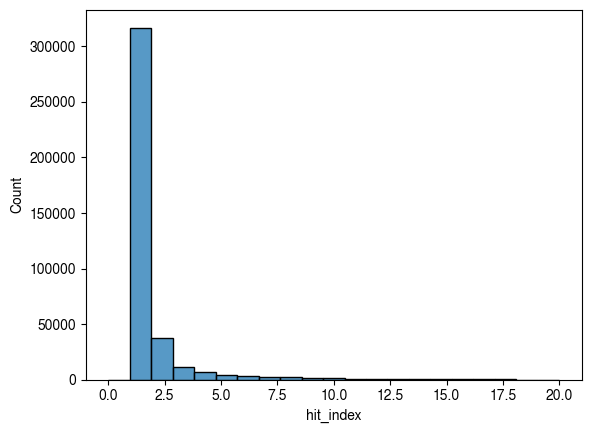

In [141]:
sns.histplot(contribution_counts, bins=21, binrange=(0, 20))


In [142]:
calo_digi_contributions.sort_values('energy', ascending=False).groupby(['event_id', 'cellID']).head(10)

,energy,time,particle_id,cellID,detector,hit_index,event_id
269265,1.385451e-01,10.676454,38507,18416344780538133009,ECalEndcapCollection,495769,0
558546,8.356705e-02,9.387915,172374,18432670324887020052,HCalEndcapCollection,952402,0
340576,8.350964e-02,15.595982,23394,24206701985988881,ECalEndcapCollection,634224,0
489095,8.219197e-02,17.026426,86001,18433514745522317588,HCalEndcapCollection,893902,0
584237,8.093644e-02,14.077730,142691,18432670333478914324,HCalEndcapCollection,1003399,0
...,...,...,...,...,...,...,...
563304,1.146304e-12,9208.515625,118168,18433514758408706580,HCalEndcapCollection,959384,0
469646,2.695515e-13,6668.444824,80202,18435203582497464852,HCalEndcapCollection,882493,0
530346,9.640644e-14,9150.573242,100768,18432951808453906964,HCalEndcapCollection,925251,0
453760,6.798473e-14,21824.111328,53008,18433233279135322644,HCalEndcapCollection,874942,0


matplotlib.category -| INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category -| INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category -| INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Bins (left edges): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Counts: [     0 316987  37181  11495   6537   4437   3585   2697   2064   1519
   1157    800    555    370    268    186    134    100     65     91]


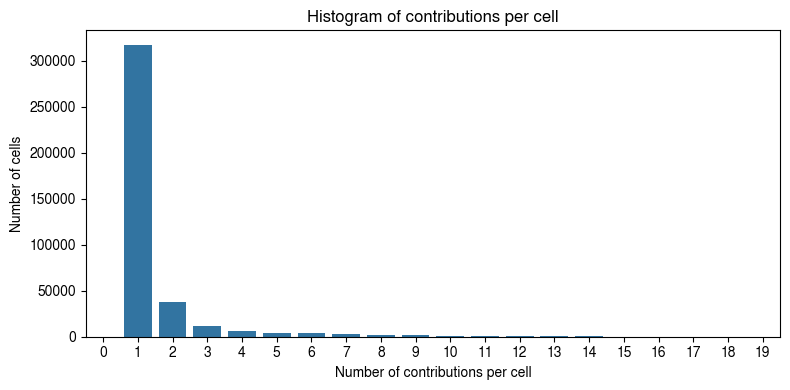

In [145]:
# histogram counts
bins = np.arange(0, 21)  # bins for 0..20 contributions
counts, edges = np.histogram(contribution_counts.values, bins=bins)

# show numeric counts and plot
print("Bins (left edges):", edges[:-1])
print("Counts:", counts)

plt.figure(figsize=(8,4))
sns.barplot(x=edges[:-1], y=counts, color='C0')
plt.xlabel('Number of contributions per cell')
plt.ylabel('Number of cells')
plt.title('Histogram of contributions per cell')
plt.xticks(edges[:-1])
plt.tight_layout()
plt.show()

In [ ]:
# Get contributions sorted by energy (descending) within each cell
contributions_sorted = calo_digi_contributions.sort_values('energy', ascending=False)

# Group by cell and get rank within each group
contributions_sorted['rank'] = contributions_sorted.groupby(['event_id', 'cellID']).cumcount() + 1

# Create separate dataframes for 1st, 2nd, 3rd, 4th contributions
first_contrib = contributions_sorted[contributions_sorted['rank'] == 1].copy()
second_contrib = contributions_sorted[contributions_sorted['rank'] == 2].copy()
third_contrib = contributions_sorted[contributions_sorted['rank'] == 3].copy()
fourth_contrib = contributions_sorted[contributions_sorted['rank'] == 4].copy()

print(f"First contributions: {len(first_contrib)}")
print(f"Second contributions: {len(second_contrib)}")
print(f"Third contributions: {len(third_contrib)}")
print(f"Fourth contributions: {len(fourth_contrib)}")

First contributions: 390400
Second contributions: 73413
Third contributions: 36232
Fourth contributions: 24737


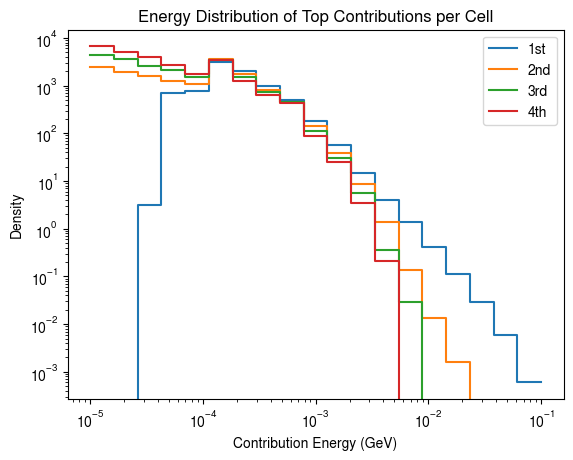

In [152]:
bins = np.logspace(-5, -1, 20)  # Log-spaced bins from 10^-5 to 10^1
sns.histplot(first_contrib['energy'], bins=bins, label='1st', color='C0', stat='density', element='step', fill=False)
sns.histplot(second_contrib['energy'], bins=bins, label='2nd', color='C1', stat='density', element='step', fill=False)
sns.histplot(third_contrib['energy'], bins=bins, label='3rd', color='C2', stat='density', element='step', fill=False)
sns.histplot(fourth_contrib['energy'], bins=bins, label='4th', color='C3', stat='density', element='step', fill=False)
plt.xlabel('Contribution Energy (GeV)')
plt.ylabel('Density')
plt.xscale('log')
plt.yscale('log')
plt.title('Energy Distribution of Top Contributions per Cell')
plt.legend()

In [153]:
first_contrib['energy'].sum() + second_contrib['energy'].sum()

np.float32(257.5048)

In [154]:
(first_contrib['energy'].sum() + second_contrib['energy'].sum()) / calo_digi_contributions['energy'].sum()

np.float32(0.9092875)